# Task 1

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (14,8)
plt.rcParams['figure.dpi'] = 40

First we import the data and define some helper functions:

In [128]:
def import_data(filename):
    df = pd.read_csv(filename,sep="\t")
    train = df[df["Type"]== 'Train']
    test = df[df["Type"]== 'Test']   

    train_features = train[["Track ID", "GenreID", "spectral_rolloff_mean","mfcc_1_mean","spectral_centroid_mean","tempo", "mfcc_1_std", "spectral_contrast_mean", "spectral_contrast_var"]]
    test_features = test[["Track ID", "GenreID", "spectral_rolloff_mean","mfcc_1_mean","spectral_centroid_mean","tempo", "mfcc_1_std", "spectral_contrast_mean", "spectral_contrast_var"]] 
    
    return train_features, test_features

def genreID_toString(genreID):
    dict = {0: "Pop", 1: "Metal", 2: "Disco", 3: "Blues", 4: "Reggae", 5: "Classical", 6: "Rock", 7: "Hiphop", 8: "Country", 9: "Jazz", } 
    return dict[genreID]

def divide_by_class(df):
    pop = df[df["GenreID"]== 0]
    metal = df[df["GenreID"]== 1]
    disco = df[df["GenreID"]== 2]
    blues = df[df["GenreID"]== 3]
    reggae = df[df["GenreID"]== 4]
    classical = df[df["GenreID"]== 5]
    rock = df[df["GenreID"]== 6]
    hiphop = df[df["GenreID"]== 7]
    country = df[df["GenreID"]== 8]
    jazz = df[df["GenreID"]== 9]
    return [pop, metal, disco, blues, reggae, classical, rock, hiphop, country, jazz]



Then we define some functions from the compendium

In [129]:
# Equation 3.8
def mahalanobis_distance(x,ref):
    d = x-ref["mu"]
    return d @ np.linalg.solve(ref["sigma"], d)

# Equation 3.9
def euclidean_distance(x,ref):
    return np.matmul(np.transpose(x - ref["mu"]),(x - ref["mu"]))

# Implements equation 3.16
def calc_mean(x,N):
    return (1/N)*sum(x)

# Implements equation 3.17
def calc_cov(x,mu,N):
    diff = x- mu
    new_cov = (diff.T @ diff)/N
    new_cov += np.eye(len(new_cov))*1e-6 # Making sure the covariance matrix will always be invertible
    return new_cov

Then we implement the k-nn classifier (Page 70 in the compendium):

In [130]:
def knn_no_clustering(x,refs,k=5):
    refs = np.array(refs)
    
    dist = np.zeros(len(refs)) 
    for i in range(len(refs)):
        ref = {"mu": refs[i][2:6]} 
        dist[i] = euclidean_distance(x,ref)

    lowest_k = np.argpartition(dist,k)[:k]
    lowest_k = refs[lowest_k]
    genreIDs = lowest_k[:,1]
    counts = np.bincount(genreIDs.astype(np.int64))
    classification = np.argmax(counts)
    return classification

### Running the k-nn classifier for task 1 

Importing data:

In [131]:
raw_training_data, test_features = import_data("./data/GenreClassData_30s.txt")
data_no_clustering = raw_training_data.to_numpy()
test_features = test_features.to_numpy()

# Normalizing the data:
train_xs = data_no_clustering[:,2:6].astype(float)
test_xs = test_features[:,2:6].astype(float)

train_mean = np.mean(train_xs,axis=0)
train_std = np.std(train_xs,axis=0)
train_std[train_std == 0] = 1e-6 # Adding epsilon to not get singular matrix

train_xs_scaled = (train_xs-train_mean)/train_std
test_xs_scaled = (test_xs-train_mean)/train_std

data_no_clustering[:,2:6] = train_xs_scaled
test_features[:, 2:6] = test_xs_scaled

raw_training_data.iloc[:, 2:6] = train_xs_scaled

Running  the k-nn classifier

In [132]:
correct_no_clustering = [0,0]

for i in range(len(test_features)):
    result = knn_no_clustering(test_features[i][2:6],data_no_clustering)
    correct = test_features[i][1] == result
    correct_no_clustering[int(correct)] += 1

# Printing accuracy
print(f"Correct without clustering: {correct_no_clustering[1]}")
print(f"Wrong: {correct_no_clustering[0]}")   

accuracy = correct_no_clustering[1]/len(test_features) 
error_rate = correct_no_clustering[0]/len(test_features) 
print(f"Accuracy without clustering: {round(accuracy*100,2)} %")
print(f"Error rate without clustering: {round(error_rate*100,2)} %")

Correct without clustering: 79
Wrong: 119
Accuracy without clustering: 39.9 %
Error rate without clustering: 60.1 %


Running again but checking each genre 

In [133]:
print("Percentage of correct predictions without clustering")
predicted = np.array([int(knn_no_clustering(test_features[i][2:6], data_no_clustering)) for i in range(len(test_features))])
for i in range(10):
    mask = test_features[:,1].astype(int) == i
    current_preds = predicted[mask]
    correct_percentage = sum(current_preds == i) / len(current_preds) * 100
    print(f"{genreID_toString(i)}: {round(correct_percentage, 2)}%")
print('\n')

Percentage of correct predictions without clustering
Pop: 65.0%
Metal: 55.0%
Disco: 50.0%
Blues: 25.0%
Reggae: 35.0%
Classical: 73.68%
Rock: 5.0%
Hiphop: 40.0%
Country: 15.79%
Jazz: 35.0%




Then implementing clustering for each genre:

In [134]:
# This function is based on the clustering procedure from the compendium on page 80-81
def cluster(data):
    genreID = data[0][1]
    # Starting with M = 1
    xs = data[:,2:6].astype(float)
    M = 1
    mu1 = calc_mean(xs,len(xs))
    cov1 = calc_cov(xs,mu1,len(xs))
    lambda1 = {"mu": mu1,"sigma": cov1}
    
    # Calculating distance
    dist = 0
    for i in range(len(xs)): 
        dist += mahalanobis_distance(xs[i],lambda1)
    D1 = dist/len(xs)
    lambdas = [lambda1]
    
    Dms = [D1]
    cluster_classifications = np.zeros(len(xs),dtype=int)
    while True:
        # Make a new cluster by adding random value to mean
        cluster_classifications_old = cluster_classifications
        M = M+1

        counts = np.bincount(cluster_classifications_old.astype(int)) 
        biggest_cluster = np.argmax(counts) 
        orig_lambda = lambdas[biggest_cluster] 
        delta = 0.05*np.sqrt(np.diag(orig_lambda["sigma"]))

        # Creating two clusters from the old biggest one, (Just moving one cluster by w like said in the algorithm from the book didn't work that well) 
        w = np.random.uniform(-delta,delta,size=len(mu1))
        l1 = {"mu": orig_lambda["mu"]-w, "sigma": orig_lambda["sigma"] } 
        l2 = {"mu": orig_lambda["mu"]+w, "sigma": orig_lambda["sigma"] } 
        lambdas[biggest_cluster] = l1
        lambdas.append(l2)
        
        # Looping over clusters to find optimal amount of clusters  
        Dm_q = 10e10
        cluster_classifications = np.zeros(len(xs))
        q = 1
        while True:
            Dm_last_q = Dm_q
            Dm_q_sum = 0
            
            # Dividing into cllusters
            for i in range(len(xs)):
                shortest_dist = np.inf

                dists = [mahalanobis_distance(xs[i],l) for l in lambdas]
                closest = np.argmin(dists)
                cluster_classifications[i] = closest

                Dm_q_sum += dists[closest]

            Dm_q = Dm_q_sum/len(xs)
            beta_1 = (Dm_last_q-Dm_q)/Dm_last_q
            if beta_1 < 0.001:
                break

            # Updating mus and sigmas for each cluster
            for i in range(len(lambdas)):
                sub_xs = xs[cluster_classifications==i]
                if len(sub_xs) != 0:
                    new_mu = calc_mean(sub_xs,len(sub_xs))
                    new_cov = calc_cov(sub_xs,new_mu,len(sub_xs))
                    lambdas[i] = {"mu": new_mu, "sigma": new_cov} 
                else:
                    # No one chose this cluster :(
                    pass
        
        Dms.append(Dm_q)
        beta = Dms[-1]/Dms[-2]
        if beta >= 0.999:
            break
    return genreID, lambdas

def knn_with_clustering(x,clusters,k=5):
    dist = np.zeros(len(clusters))
    for i in range(len(clusters)):
        dist[i] = mahalanobis_distance(x,clusters[i])
    
    clusters_array = np.array(clusters)
    lowest_k_indices = np.argpartition(dist,k)[:k]
    
    genreIDs = [clusters[i]["genre"] for i in lowest_k_indices]
    counts = np.bincount(genreIDs)
    classification = np.argmax(counts)
    return classification

Running the k-nn again but with clustering

In [135]:
hmms = raw_training_data
num_genres = 10

data = divide_by_class(hmms)
clusters = [None]*num_genres
for i in range(len(data)):
    genreID, new_cluster = cluster(data[i].to_numpy())
    genreID = int(genreID)
    clusters[genreID] = new_cluster

# Adding genreid as the last item to all the datapoints
data_with_genreid = []
for i in range(len(clusters)):
    for j in range(len(clusters[i])):
        newdata = clusters[i][j]
        entry = {
            "mu": newdata["mu"],
            "sigma": newdata["sigma"],
            "genre": i
        }
        data_with_genreid.append(entry)
    print(f"Clusters for genre {i}: {j}")

counts_with_clustering = [0,0]
for i in range(len(test_features)):
    res = int(knn_with_clustering(test_features[i][2:6],data_with_genreid,k=1))
    correct = res == test_features[i][1]
    counts_with_clustering[int(correct)] += 1

print("\nPercentage results after clustering")
predicted_wc = np.array([int(knn_with_clustering(test_features[i][2:6], data_with_genreid, k=1)) for i in range(len(test_features))])
for i in range(10):
    mask = test_features[:,1].astype(int) == i
    current_preds = predicted_wc[mask]
    correct_percentage = sum(current_preds == i) / len(current_preds) * 100
    print(f"{genreID_toString(i)}: {round(correct_percentage, 2)}%")
print('\n')

print(f"Correct with clustering: {counts_with_clustering[1]}")
print(f"Wrong: {counts_with_clustering[0]}")
accuracy = counts_with_clustering[1]/len(test_features) 
error_rate = counts_with_clustering[0]/len(test_features) 

print(f"Accuracy with clustering: {round(accuracy*100,2)} %")
print(f"Error rate with clustering: {round(error_rate*100,2)} %")

Clusters for genre 0: 2
Clusters for genre 1: 1
Clusters for genre 2: 2
Clusters for genre 3: 4
Clusters for genre 4: 4
Clusters for genre 5: 2
Clusters for genre 6: 2
Clusters for genre 7: 2
Clusters for genre 8: 2
Clusters for genre 9: 2

Percentage results after clustering
Pop: 45.0%
Metal: 70.0%
Disco: 5.0%
Blues: 25.0%
Reggae: 25.0%
Classical: 73.68%
Rock: 5.0%
Hiphop: 35.0%
Country: 21.05%
Jazz: 50.0%


Correct with clustering: 70
Wrong: 128
Accuracy with clustering: 35.35 %
Error rate with clustering: 64.65 %


# Task 2

Here we visualize different features to see which ones are having the most effect and which ones aren't

In [136]:
def divide_by_class_string(df):
    pop = df[df["GenreID"]== '0']
    metal = df[df["GenreID"]== '1']
    disco = df[df["GenreID"]== '2']
    blues = df[df["GenreID"]== '3']
    reggae = df[df["GenreID"]== '4']
    classical = df[df["GenreID"]== '5']
    rock = df[df["GenreID"]== '6']
    hiphop = df[df["GenreID"]== '7']
    country = df[df["GenreID"]== '8']
    jazz = df[df["GenreID"]== '9']
    return [pop, metal, disco, blues, reggae, classical, rock, hiphop, country, jazz]

def fetch_features():
    train_features, _ = import_data("./data/GenreClassData_30s.txt")
    train_features['GenreID'] = train_features['GenreID'].astype(str)
    classes = divide_by_class_string(train_features)
    
    pop = classes[0]
    metal = classes[1]
    disco = classes[2]
    classical = classes[5]

    pop_features = pop.to_numpy()[:, 2:9]
    metal_features = metal.to_numpy()[:, 2:9]
    disco_features = disco.to_numpy()[:, 2:9]
    classical_features = classical.to_numpy()[:, 2:9]

    return pop_features, metal_features, disco_features, classical_features

# Plotting all genres overlaying each other
def plot_histogram_overlay(genre, ax, color, label):
    N = 20
    
    ax[0][0].hist(genre[:, 0], bins = N, color = color, label = label, alpha = 0.8)
    ax[0][0].set_title('Spectral rolloff mean')
    ax[0][0].legend()

    ax[0][1].hist(genre[:, 1], bins = N, color = color, label = label, alpha = 0.8)
    ax[0][1].set_title('Mel-frequency cepstrum mean')
    ax[0][1].legend()

    ax[1][0].hist(genre[:, 2], bins = N, color = color, label = label, alpha = 0.8)
    ax[1][0].set_title('Spectral centroid mean')
    ax[1][0].legend()

    ax[1][1].hist(genre[:, 3], bins = N, color = color, label = label, alpha = 0.8)
    ax[1][1].set_title('Tempo')
    ax[1][1].legend()

# Plotting all features, per genre
def plot_feature_histogram(pop, metal, disco, classical, ax, fig, color, title, feature):
    N = 50
    
    # feature = 0: spectral rolloff mean
    # feature = 1: mfcc_mean
    # feature = 2: spectral centroid mean
    # feature = 3: tempo
    # feature = 4: mel-frequency cepstrum standard deviation
    # feature = 5: spectral contrast mean
    # feature = 6: spectral contrast variance

    xmin = min(
        np.min(pop[:, feature]),
        np.min(metal[:, feature]),
        np.min(disco[:, feature]),
        np.min(classical[:, feature])
    )
    
    xmax = max(
        np.max(pop[:, feature]),
        np.max(metal[:, feature]),
        np.max(disco[:, feature]),
        np.max(classical[:, feature])
    )

    ax[0].hist(pop[:, feature], bins=N, color=color, alpha=0.8)
    ax[0].set(xlim=(xmin, xmax))
    ax[0].set_title('Pop')

    ax[1].hist(metal[:, feature], bins = N, color = color, alpha = 0.8)
    ax[1].set(xlim=(xmin, xmax))
    ax[1].set_title('Metal')

    ax[2].hist(disco[:, feature], bins = N, color = color, alpha = 0.8)
    ax[2].set(xlim=(xmin, xmax))
    ax[2].set_title('Disco')

    ax[3].hist(classical[:, feature], bins = N, color = color, alpha = 0.8)
    ax[3].set(xlim=(xmin, xmax))
    ax[3].set_title('Classical')

    fig.suptitle(title)

def visualize_distribution():
    pop, metal, disco, classical = fetch_features()
    
    NUM_PLOTS = 4

    fig0, ax0 = plt.subplots(NUM_PLOTS, 1)
    plot_feature_histogram(pop, metal, disco, classical, ax0, fig0, 'blue', 'Spectral Rolloff Mean Histogram', 0)
    
    fig1, ax1 = plt.subplots(NUM_PLOTS, 1)
    plot_feature_histogram(pop, metal, disco, classical, ax1, fig1, 'orange', 'Mel-frequency Cepstrum Mean Histogram', 1)

    fig2, ax2 = plt.subplots(NUM_PLOTS, 1)
    plot_feature_histogram(pop, metal, disco, classical, ax2, fig2, 'purple', 'Spectral Controid Mean Histogram', 2)

    fig3, ax3 = plt.subplots(NUM_PLOTS, 1)
    plot_feature_histogram(pop, metal, disco, classical, ax3, fig3, 'green', 'Tempo Histogram', 3)

    fig4, ax6 = plt.subplots(NUM_PLOTS, 1)
    plot_feature_histogram(pop, metal, disco, classical, ax6, fig4, 'black', 'Spectral Contrast Variance', 6)

    plt.tight_layout()
    plt.show()

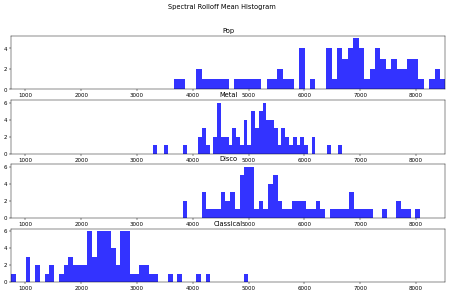

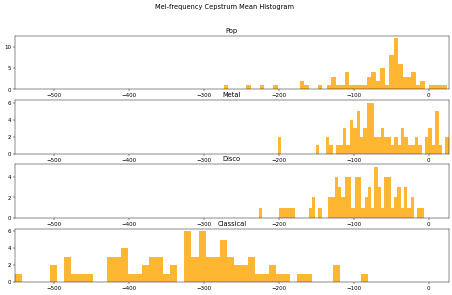

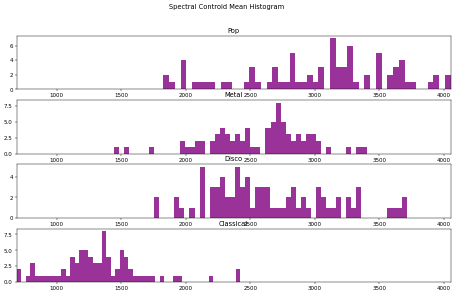

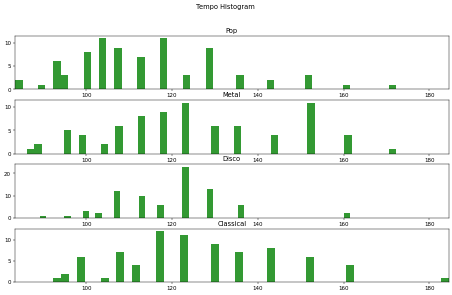

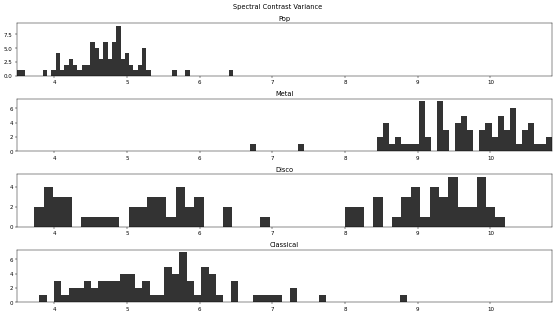

In [137]:
visualize_distribution()

Here it is pretty clear that the feature which is the least distinct for these four classes is tempo. Therefore we will not use tempo for task 3 and instead use spectral contrast variance

# Task 3

In [138]:
def knn_no_clustering_3(x,refs,k=5):
    refs = np.array(refs)
    
    dist = np.zeros(len(refs)) 
    for i in range(len(refs)):
        ref = {"mu": refs[i][2:5]+ [refs[i][8]]} 
        dist[i] = euclidean_distance(x,ref)

    lowest_k = np.argpartition(dist,k)[:k]
    lowest_k = refs[lowest_k]
    genreIDs = lowest_k[:,1]
    counts = np.bincount(genreIDs.astype(np.int64))
    classification = np.argmax(counts)
    return classification

In [139]:
correct_no_clustering = [0,0]

for i in range(len(test_features)):
    result = knn_no_clustering_3(test_features[i][2:5]+[test_features[i][8]],data_no_clustering)
    correct = test_features[i][1] == result
    correct_no_clustering[int(correct)] += 1
    
# Printing accuracy
print(f"Correct without clustering: {correct_no_clustering[1]}")
print(f"Wrong: {correct_no_clustering[0]}")   

accuracy = correct_no_clustering[1]/len(test_features) 
error_rate = correct_no_clustering[0]/len(test_features) 
print(f"Accuracy without clustering: {round(accuracy*100,2)} %")
print(f"Error rate without clustering: {round(error_rate*100,2)} %")

Correct without clustering: 60
Wrong: 138
Accuracy without clustering: 30.3 %
Error rate without clustering: 69.7 %


In [140]:
print("Percentage of correct predictions without clustering")
predicted = np.array([int(knn_no_clustering_3(test_features[i][2:5]+[test_features[i][8]], data_no_clustering)) for i in range(len(test_features))])
for i in range(10):
    mask = test_features[:,1].astype(int) == i
    current_preds = predicted[mask]
    correct_percentage = sum(current_preds == i) / len(current_preds) * 100
    print(f"{genreID_toString(i)}: {round(correct_percentage, 2)}%")
print('\n')

Percentage of correct predictions without clustering


Pop: 60.0%
Metal: 80.0%
Disco: 25.0%
Blues: 20.0%
Reggae: 25.0%
Classical: 52.63%
Rock: 0.0%
Hiphop: 20.0%
Country: 10.53%
Jazz: 10.0%




Using spectral contrast variance instead of tempo did not seem to give any significant improvements to the k-nn classifier

# Task 4

Here a multilayer perceptron was designed

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [142]:
class NeuralNetwork(nn.Module):
    def __init__(self,in_features=62,h1=32,h2=16,out_features=10):
        super().__init__()
        self.fc1 = nn.Linear(in_features,h1)
        self.fc2 = nn.Linear(h1,h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x)) 
        x = F.relu(self.fc2(x))
        x = self.out(x) 
        return x

class Dataset:
    def __init__(self, dataframe):
        self.raw_data = dataframe.to_numpy()
        self.ids = self.raw_data[:,0]
        self.genres = self.raw_data[:,1].astype(int)
        self.features = self.raw_data[:,2:]

    def get_genre(self,genreid):
        mask = self.genres == genreid
        return self.features[mask]

def import_data_nn(filename: str, features: list[str]) -> tuple[Dataset,Dataset]:
    df = pd.read_csv(filename,sep="\t")

    train = df[df["Type"]== 'Train']
    test = df[df["Type"]== 'Test']   

    train_features = train[["Track ID", "GenreID"]+features]
    test_features = test[["Track ID", "GenreID"]+features] 
    
    training_dataset = Dataset(train_features)
    testing_dataset = Dataset(test_features)
    return training_dataset, testing_dataset


6


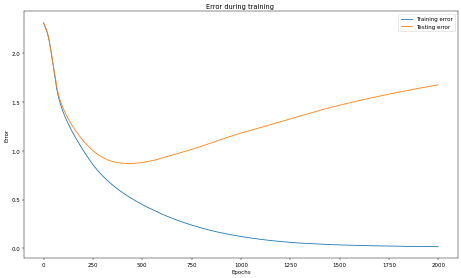

In [143]:
# Importing and preparing data:
using_features = ["zero_cross_rate_mean", "zero_cross_rate_std", "rmse_mean", "rmse_var", "spectral_centroid_mean", "spectral_centroid_var", "spectral_bandwidth_mean", "spectral_bandwidth_var", "spectral_rolloff_mean", "spectral_rolloff_var", "spectral_contrast_mean", "spectral_contrast_var", "spectral_flatness_mean", "spectral_flatness_var", "chroma_stft_1_mean", "chroma_stft_2_mean", "chroma_stft_3_mean", "chroma_stft_4_mean", "chroma_stft_5_mean", "chroma_stft_6_mean", "chroma_stft_7_mean", "chroma_stft_8_mean", "chroma_stft_9_mean", "chroma_stft_10_mean", "chroma_stft_11_mean", "chroma_stft_12_mean", "chroma_stft_1_std", "chroma_stft_2_std", "chroma_stft_3_std", "chroma_stft_4_std", "chroma_stft_5_std", "chroma_stft_6_std", "chroma_stft_7_std", "chroma_stft_8_std", "chroma_stft_9_std", "chroma_stft_10_std", "chroma_stft_11_std", "chroma_stft_12_std", "tempo", "mfcc_1_mean", "mfcc_2_mean", "mfcc_3_mean", "mfcc_4_mean", "mfcc_5_mean", "mfcc_6_mean", "mfcc_7_mean", "mfcc_8_mean", "mfcc_9_mean", "mfcc_10_mean", "mfcc_11_mean", "mfcc_12_mean", "mfcc_1_std", "mfcc_2_std", "mfcc_3_std", "mfcc_4_std", "mfcc_5_std", "mfcc_6_std", "mfcc_7_std", "mfcc_8_std", "mfcc_9_std", "mfcc_10_std", "mfcc_11_std", "mfcc_12_std"]
datafile = "./data/GenreClassData_30s.txt"
training_data, testing_data = import_data_nn(datafile,using_features)

torch.manual_seed(69)
model = NeuralNetwork(in_features=len(using_features))
params = list(model.parameters())
print(len(params))

# Scaling the data:
scaler = StandardScaler()
training_data.features = scaler.fit_transform(training_data.features)
testing_data.features = scaler.fit_transform(testing_data.features)

x_train = torch.from_numpy(training_data.features)    
x_train = x_train.type(torch.float)
y_train = torch.from_numpy(training_data.genres).type(torch.long) 

x_test = torch.from_numpy(testing_data.features).type(torch.float)
y_test = torch.from_numpy(testing_data.genres).type(torch.long) 

# Training neural network
optimizer = optim.SGD(model.parameters(), lr=0.1)
epochs = 2000

criterion = nn.CrossEntropyLoss()
training_losses = np.zeros(epochs)
testing_losses = np.zeros(epochs)
for i in range(epochs): 
    training_output = model(x_train)
    target = y_train

    testing_output = model(x_test)
    training_loss = criterion(training_output,target)
    testing_loss = criterion(testing_output,y_test) 

    training_losses[i] = training_loss.item()
    testing_losses[i] = testing_loss.item()

    if i % 50 == 0:
        pass

    optimizer.zero_grad()
    training_loss.backward()
    optimizer.step()

outputs = model(x_test)
_, predicted = torch.max(outputs,1)

correct = (predicted == y_test).sum().item()
total = len(y_test)

plt.plot(training_losses,label= "Training error")
plt.plot(testing_losses,label= "Testing error")

plt.title("Error during training ")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.show()

As we can see the model seems to be overfitting to the training data after about 400 epochs

Printing confusion matrix etc:

In [144]:
cm = confusion_matrix(y_test.cpu().numpy(), predicted.cpu().numpy())
print(f'CONFUSION MATRIX: \n{cm}')

print(f"Correct: {correct} ")
print(f"Total: {total}")

accuracy = correct/total
print(f"Accuracy: {round(accuracy*100,2)} %")
print(f"Error rate: {round(100-accuracy*100,2)} %")

# Sorting results based on genre
print("\nPercentage of correct classifications by genre")
for i in range(10):
    current_genre = genreID_toString(i)
    mask = y_test == i
    current_preds = predicted[mask]
    num_thisgenre = len(current_preds)
    correct_count = sum(current_preds == i)
    correct_percentage = correct_count/num_thisgenre
    percentage_num = correct_percentage.item()*100

    print(f"{current_genre}: {round(percentage_num,2)}%")

CONFUSION MATRIX: 
[[16  0  1  0  1  0  0  0  2  0]
 [ 0 20  0  0  0  0  0  0  0  0]
 [ 0  1  8  2  0  0  5  2  1  1]
 [ 0  0  0 13  0  0  2  2  1  2]
 [ 0  0  2  1 14  0  1  1  1  0]
 [ 0  0  0  0  1 16  0  0  0  2]
 [ 1  2  3  2  2  1  8  0  1  0]
 [ 0  0  2  0  1  0  0 17  0  0]
 [ 0  0  2  0  0  0  6  0 10  1]
 [ 0  0  0  0  1  1  0  0  0 18]]
Correct: 140 
Total: 198
Accuracy: 70.71 %
Error rate: 29.29 %

Percentage of correct classifications by genre
Pop: 80.0%
Metal: 100.0%
Disco: 40.0%
Blues: 65.0%
Reggae: 70.0%
Classical: 84.21%
Rock: 40.0%
Hiphop: 85.0%
Country: 52.63%
Jazz: 90.0%
